In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms
import scipy.stats as ststs
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../data/processed/RIT+Opportunity+Wise+Data+-+Sheet1.csv")
df.head()

,Learner SignUp DateTime,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity End Date,First Name,Date of Birth,Gender,Country,Institution Name,Current/Intended Major,Entry created at,Status Description,Status Code,Apply Date,Opportunity Start Date
0,06/14/2023 12:30:35,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,06/29/2024 18:52:39,Faria,01/12/2001,Female,Pakistan,Nwihs,Radiology,03/11/2024 12:01:41,Started,1080,06/14/2023 12:36:09,11/03/2022 18:30:39
1,05/01/2023 05:29:16,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,06/29/2024 18:52:39,Poojitha,08/16/2000,Female,India,SAINT LOUIS,Information Systems,03/11/2024 12:01:41,Started,1080,05/01/2023 06:08:21,11/03/2022 18:30:39
2,04/09/2023 20:35:08,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,06/29/2024 18:52:39,Emmanuel,01/27/2002,Male,United States,Illinois Institute of Technology,Computer Science,03/11/2024 12:01:41,Started,1080,05/11/2023 1085640:21:29,11/03/2022 18:30:39
3,08/29/2023 05:20:03,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,06/29/2024 18:52:39,Amrutha Varshini,11/01/1999,Female,United States,Saint Louis University,Information Systems,03/11/2024 12:01:41,Team Allocated,1070,10/09/2023 22:02:42,11/03/2022 18:30:39
4,01/06/2023 15:26:36,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,06/29/2024 18:52:39,Vinay Varshith,04/19/2000,Male,United States,Saint Louis University,Computer Science,03/11/2024 12:01:41,Started,1080,01/06/2023 15:40:10,11/03/2022 18:30:39


In [4]:
df.shape

(8558, 16)

<Axes: >

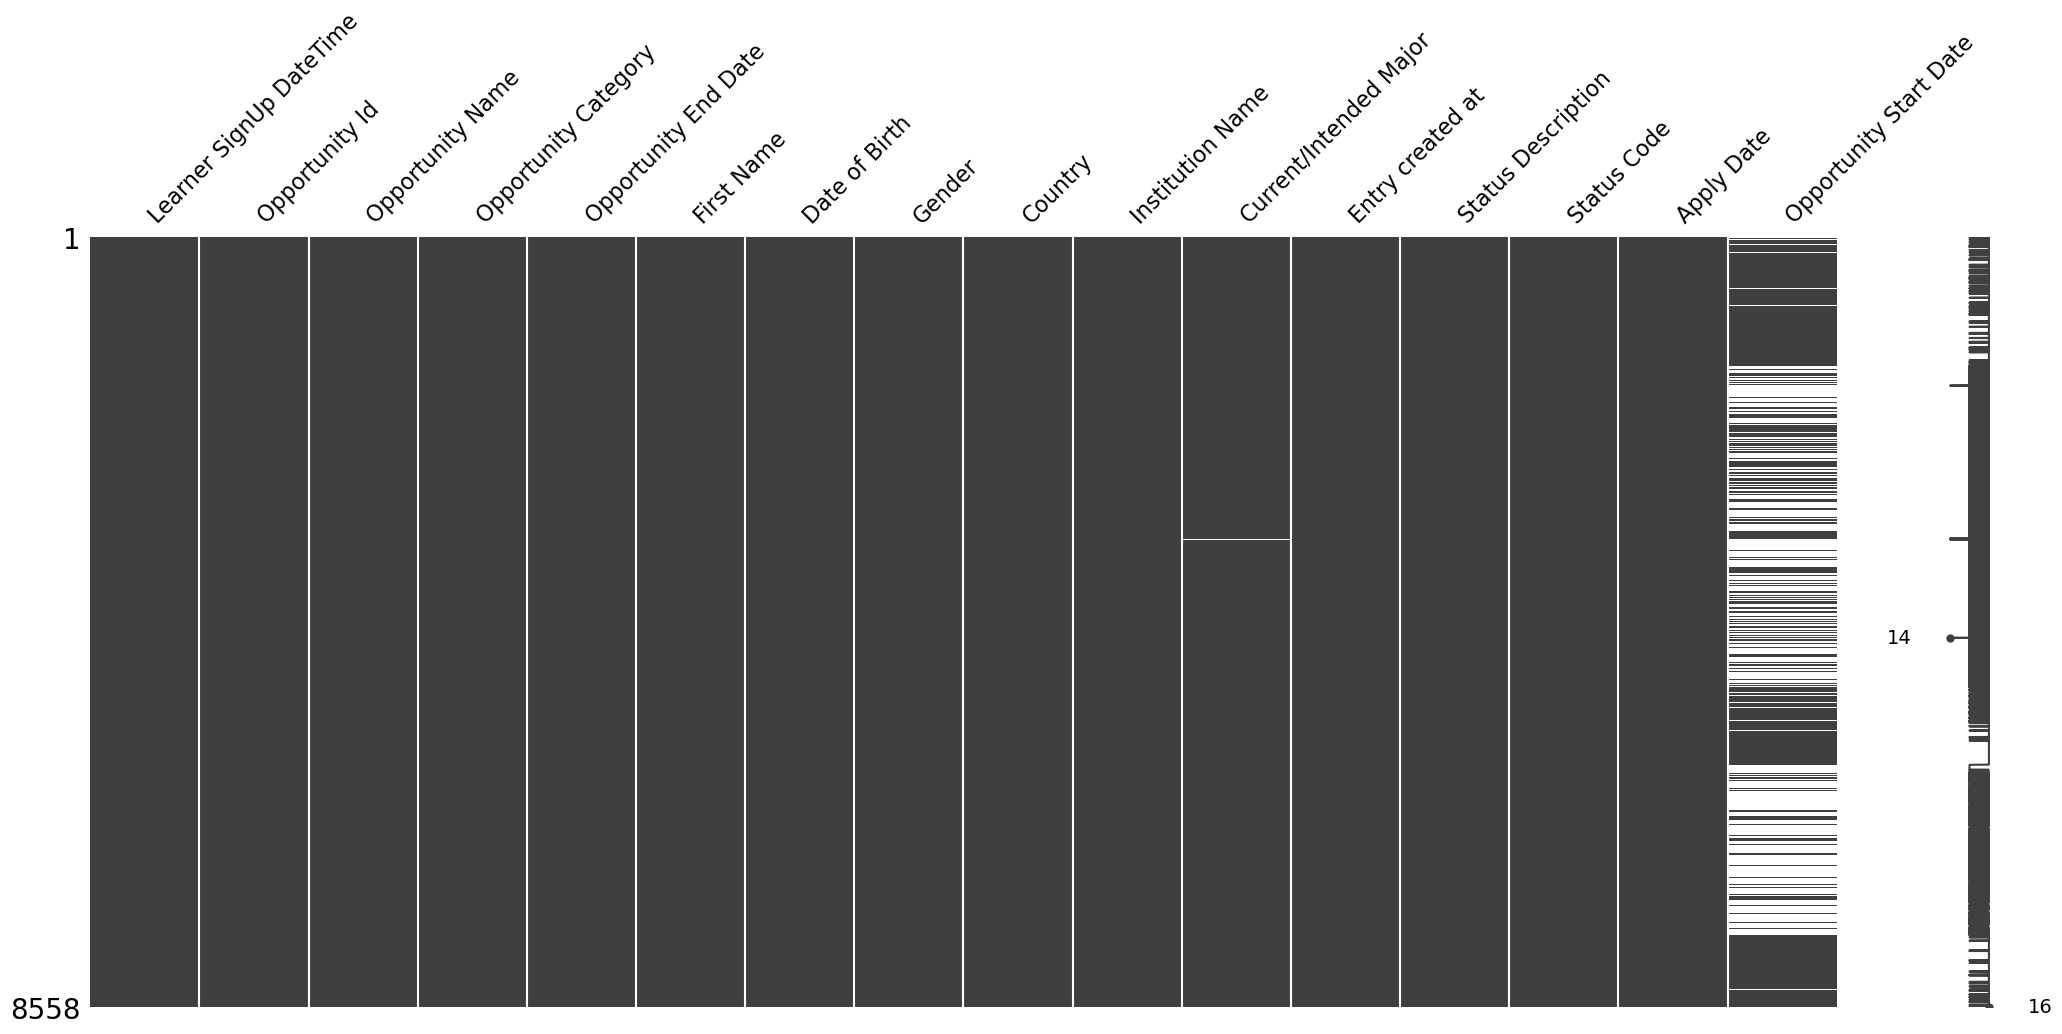

In [5]:
ms.matrix(df)

In [47]:
df['Institution Name'].to_csv('institutions.csv')

<Axes: >

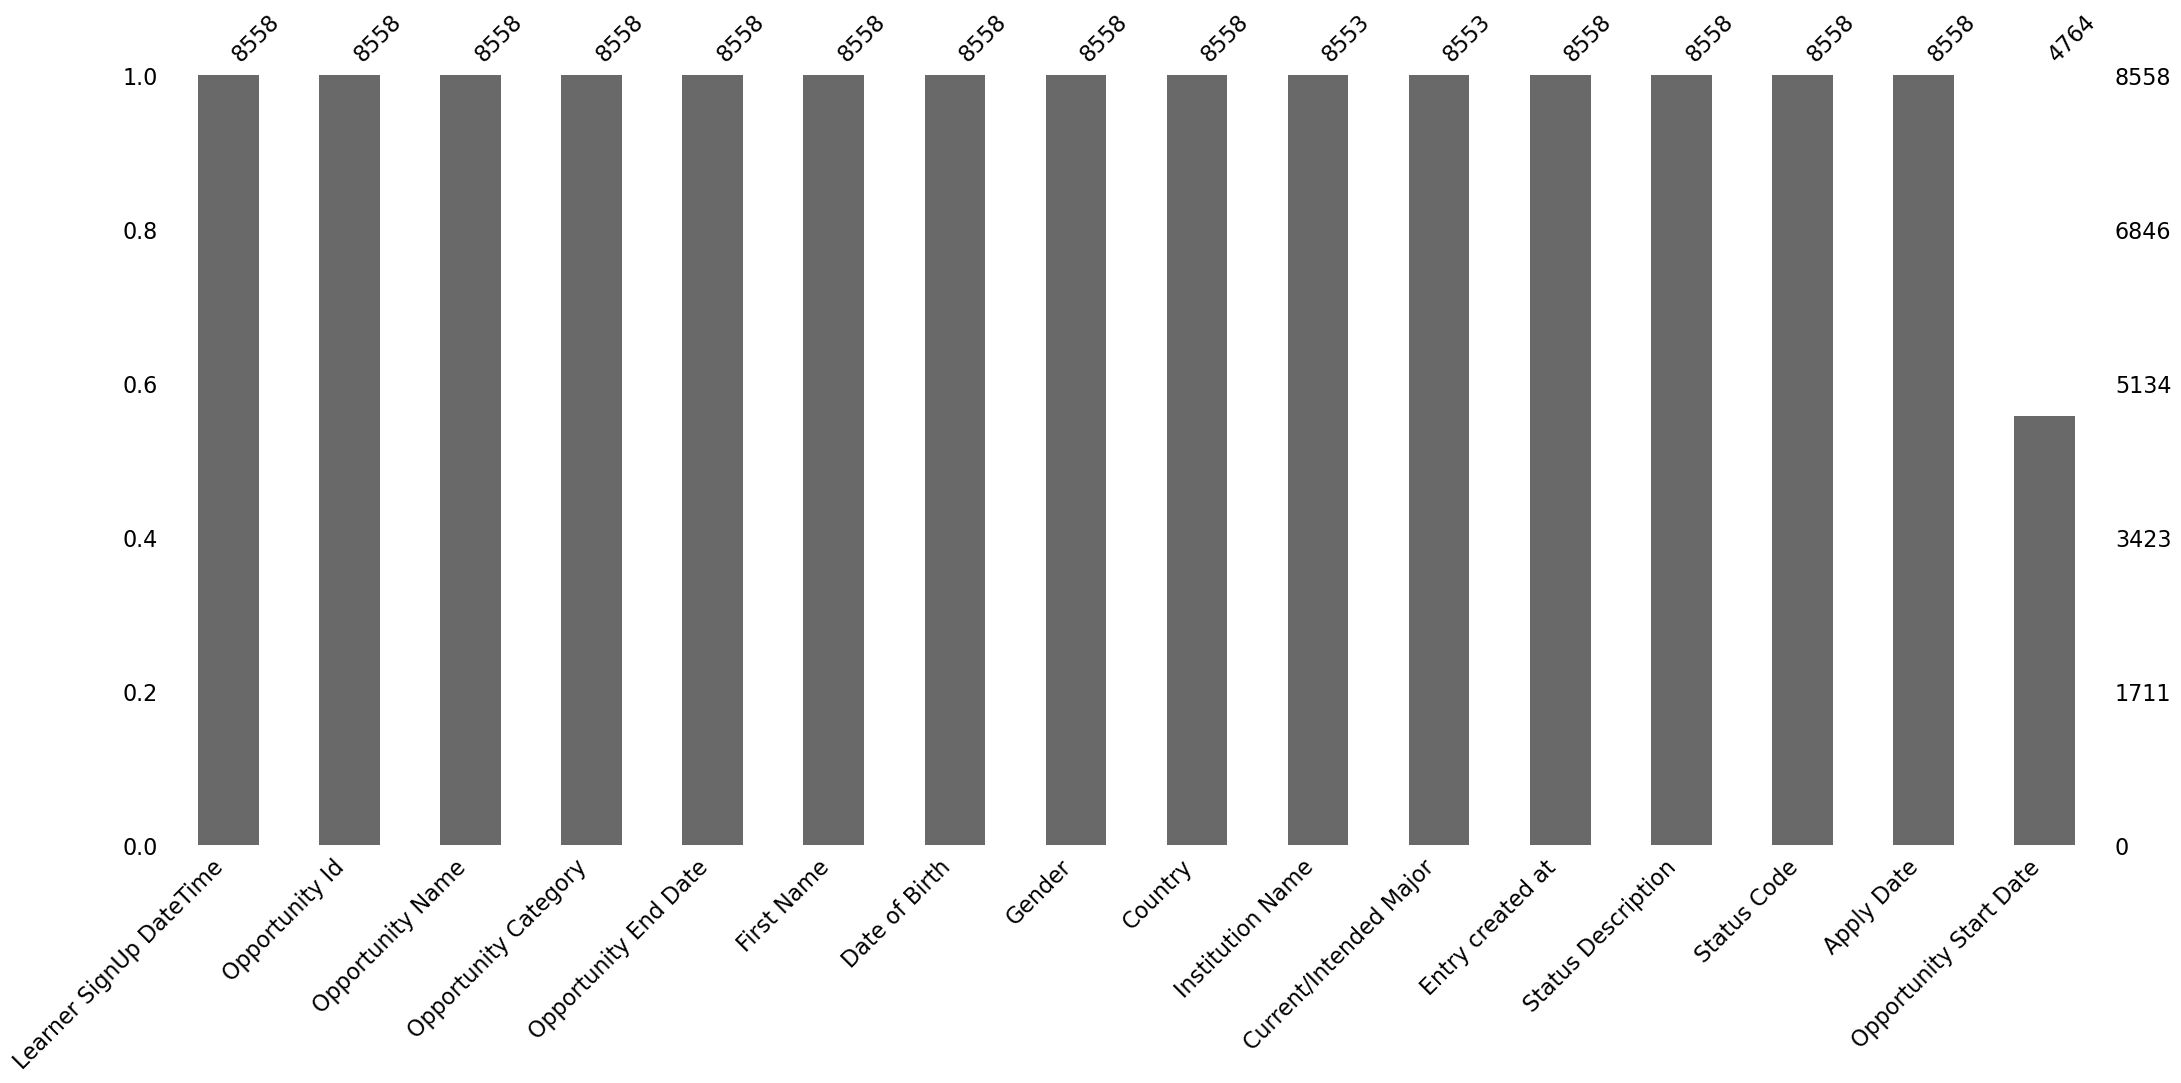

In [6]:
ms.bar(df)

In [7]:
df['Current/Intended Major'].isna().sum()

np.int64(5)

In [8]:
df['Opportunity Start Date'].value_counts()

Opportunity Start Date
11/03/2022 18:30:39         1361
01/08/2024 03:30:46          988
01/22/2024 24:00:00          499
03/20/2023 02:30:00          341
02/17/2024 14:00:00          262
03/08/2024 14:00:00          222
01/28/2024 23:30:00          186
03/05/2024 1089960:00:00     153
03/21/2024 18:30:00          136
08/21/2023 06:30:54          118
01/28/2024 18:30:00          113
02/15/2024 18:30:00          110
02/19/2024 24:00:00          106
04/04/2024 1089264:00:00      49
04/30/2024 13:36:47           43
03/18/2024 24:00:00           36
06/06/2023 11:06:00           33
05/31/2024 07:04:54            8
Name: count, dtype: int64

In [9]:
df['Opportunity End Date'].value_counts()

Opportunity End Date
03/11/2024 18:00:00         4159
06/29/2024 18:52:39         1423
04/12/2024 1095120:00:00     784
04/11/2024 1094400:00:00     478
06/30/2024 16:18:50          389
02/17/2024 11:30:00          262
03/08/2024 11:30:00          237
12/24/2025 03:34:00          192
04/29/2024 18:29:00          138
12/05/2025 12:59:00          121
03/13/2024 18:29:00          116
04/19/2024 18:29:00          112
10/31/2023 14:45:36           55
04/23/2024 16:36:47           46
12/05/2025 11:06:00           33
12/06/2025 10:26:00            9
03/01/2023 11:36:46            4
Name: count, dtype: int64

In [10]:
df['Learner SignUp DateTime'].value_counts()

Learner SignUp DateTime
02/21/2024 14:37:12    16
01/31/2024 15:11:57    16
01/03/2024 17:13:01    16
02/02/2024 21:06:36    16
01/05/2023 16:33:15    16
                       ..
02/12/2024 12:44:38     1
09/25/2023 07:12:18     1
02/22/2024 20:51:43     1
03/05/2024 19:04:55     1
07/20/2023 04:25:28     1
Name: count, Length: 3916, dtype: int64

In [11]:
df['Entry created at'].value_counts()

Entry created at
03/11/2024 12:02:04    141
03/11/2024 12:02:17    126
03/11/2024 12:02:57    123
03/11/2024 12:02:12    121
03/11/2024 12:02:05    121
                      ... 
03/11/2024 12:02:46     71
03/11/2024 12:02:45     70
03/11/2024 12:01:57     69
03/11/2024 12:02:40     65
03/11/2024 12:02:25     56
Name: count, Length: 94, dtype: int64

In [12]:
df['Apply Date'].value_counts()

Apply Date
08/29/2023 05:30:24    3
02/21/2024 06:01:42    2
01/05/2024 04:38:47    2
01/17/2024 19:23:52    2
08/20/2023 04:53:48    2
                      ..
02/04/2024 18:04:51    1
01/28/2024 20:38:53    1
03/06/2024 17:28:37    1
03/08/2024 07:37:14    1
10/09/2023 22:02:42    1
Name: count, Length: 8548, dtype: int64

In [13]:
nan_start_date = df['Opportunity Start Date'].isnull().sum()

In [14]:
nan_start_date

np.int64(3794)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8558 entries, 0 to 8557
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Learner SignUp DateTime  8558 non-null   object
 1   Opportunity Id           8558 non-null   object
 2   Opportunity Name         8558 non-null   object
 3   Opportunity Category     8558 non-null   object
 4   Opportunity End Date     8558 non-null   object
 5   First Name               8558 non-null   object
 6   Date of Birth            8558 non-null   object
 7   Gender                   8558 non-null   object
 8   Country                  8558 non-null   object
 9   Institution Name         8553 non-null   object
 10  Current/Intended Major   8553 non-null   object
 11  Entry created at         8558 non-null   object
 12  Status Description       8558 non-null   object
 13  Status Code              8558 non-null   int64 
 14  Apply Date               8558 non-null  

In [17]:
import pandas as pd
from datetime import timedelta

# Charger le dataset
df = pd.read_csv(r"C:\Users\ferna\Downloads\Dataset\Excelerate 1st Week\data\RIT+Opportunity+Wise+Data+-+Sheet1.csv")

# Colonnes à corriger
cols_to_fix = ["Opportunity Start Date", "Opportunity End Date"]

for col in cols_to_fix:
    # Convertir en datetime avec gestion des erreurs
    df[col] = pd.to_datetime(df[col], errors="coerce")

    # Identifier les lignes avec heure = 24:00:00 (représentées comme NaT car invalide)
    mask_invalid = df[col].isna()

    # Récupérer les valeurs originales pour correction
    original_values = pd.read_csv(r"C:\Users\ferna\Downloads\Dataset\Excelerate 1st Week\data\RIT+Opportunity+Wise+Data+-+Sheet1.csv")[col]

    # Corriger manuellement : remplacer "24:00:00" par "00:00:00" et ajouter +1 jour
    corrected = []
    for val in original_values:
        if isinstance(val, str) and "24:00:00" in val:
            date_part = val.split()[0]
            corrected_date = pd.to_datetime(date_part) + timedelta(days=1)
            corrected.append(str(corrected_date.date()) + " 00:00:00")
        else:
            corrected.append(val)

    # Réinjecter les valeurs corrigées
    df[col] = pd.to_datetime(corrected, errors="coerce")

# Sauvegarder le dataset corrigé
#df.to_csv(r"C:\Users\ferna\Downloads\Dataset\Excelerate 1st Week\data\RIT+Opportunity+Wise+Data+-+Sheet1_corrected.csv", index=False)


In [18]:
df['Opportunity Start Date'].value_counts()

Opportunity Start Date
2022-11-03 18:30:39    1361
2024-01-08 03:30:46     988
2023-03-20 02:30:00     341
2024-02-17 14:00:00     262
2024-03-08 14:00:00     222
2024-01-28 23:30:00     186
2024-03-21 18:30:00     136
2023-08-21 06:30:54     118
2024-01-28 18:30:00     113
2024-02-15 18:30:00     110
2024-04-30 13:36:47      43
2023-06-06 11:06:00      33
2024-05-31 07:04:54       8
Name: count, dtype: int64

In [19]:
df['Learner SignUp DateTime'] = pd.to_datetime(df['Learner SignUp DateTime'], errors='coerce')

In [20]:
df['Learner SignUp DateTime']

0      2023-06-14 12:30:35
1      2023-05-01 05:29:16
2      2023-04-09 20:35:08
3      2023-08-29 05:20:03
4      2023-01-06 15:26:36
               ...        
8553   2024-03-05 16:39:21
8554   2024-03-06 15:58:47
8555   2024-02-29 15:02:31
8556   2023-12-23 03:53:12
8557   2023-06-01 13:22:01
Name: Learner SignUp DateTime, Length: 8558, dtype: datetime64[ns]

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8558 entries, 0 to 8557
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Learner SignUp DateTime  8263 non-null   datetime64[ns]
 1   Opportunity Id           8558 non-null   object        
 2   Opportunity Name         8558 non-null   object        
 3   Opportunity Category     8558 non-null   object        
 4   Opportunity End Date     7296 non-null   datetime64[ns]
 5   First Name               8558 non-null   object        
 6   Date of Birth            8558 non-null   object        
 7   Gender                   8558 non-null   object        
 8   Country                  8558 non-null   object        
 9   Institution Name         8553 non-null   object        
 10  Current/Intended Major   8553 non-null   object        
 11  Entry created at         8558 non-null   object        
 12  Status Description       8558 non-

In [22]:
df['Apply Date'] = pd.to_datetime(df['Apply Date'], errors='coerce')

In [23]:
df['Entry created at'] = pd.to_datetime(df['Entry created at'], errors='coerce')

In [24]:
df['Date of Birth'] = pd.to_datetime(df['Date of Birth'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8558 entries, 0 to 8557
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Learner SignUp DateTime  8263 non-null   datetime64[ns]
 1   Opportunity Id           8558 non-null   object        
 2   Opportunity Name         8558 non-null   object        
 3   Opportunity Category     8558 non-null   object        
 4   Opportunity End Date     7296 non-null   datetime64[ns]
 5   First Name               8558 non-null   object        
 6   Date of Birth            8558 non-null   datetime64[ns]
 7   Gender                   8558 non-null   object        
 8   Country                  8558 non-null   object        
 9   Institution Name         8553 non-null   object        
 10  Current/Intended Major   8553 non-null   object        
 11  Entry created at         8558 non-null   datetime64[ns]
 12  Status Description       8558 non-

In [26]:
df['Status Code'] = df['Status Code'].astype('int')

In [27]:
df.head()

,Learner SignUp DateTime,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity End Date,First Name,Date of Birth,Gender,Country,Institution Name,Current/Intended Major,Entry created at,Status Description,Status Code,Apply Date,Opportunity Start Date
0,2023-06-14 12:30:35,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Faria,2001-01-12,Female,Pakistan,Nwihs,Radiology,2024-03-11 12:01:41,Started,1080,2023-06-14 12:36:09,2022-11-03 18:30:39
1,2023-05-01 05:29:16,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Poojitha,2000-08-16,Female,India,SAINT LOUIS,Information Systems,2024-03-11 12:01:41,Started,1080,2023-05-01 06:08:21,2022-11-03 18:30:39
2,2023-04-09 20:35:08,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Emmanuel,2002-01-27,Male,United States,Illinois Institute of Technology,Computer Science,2024-03-11 12:01:41,Started,1080,NaT,2022-11-03 18:30:39
3,2023-08-29 05:20:03,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Amrutha Varshini,1999-11-01,Female,United States,Saint Louis University,Information Systems,2024-03-11 12:01:41,Team Allocated,1070,2023-10-09 22:02:42,2022-11-03 18:30:39
4,2023-01-06 15:26:36,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Vinay Varshith,2000-04-19,Male,United States,Saint Louis University,Computer Science,2024-03-11 12:01:41,Started,1080,2023-01-06 15:40:10,2022-11-03 18:30:39


<Axes: >

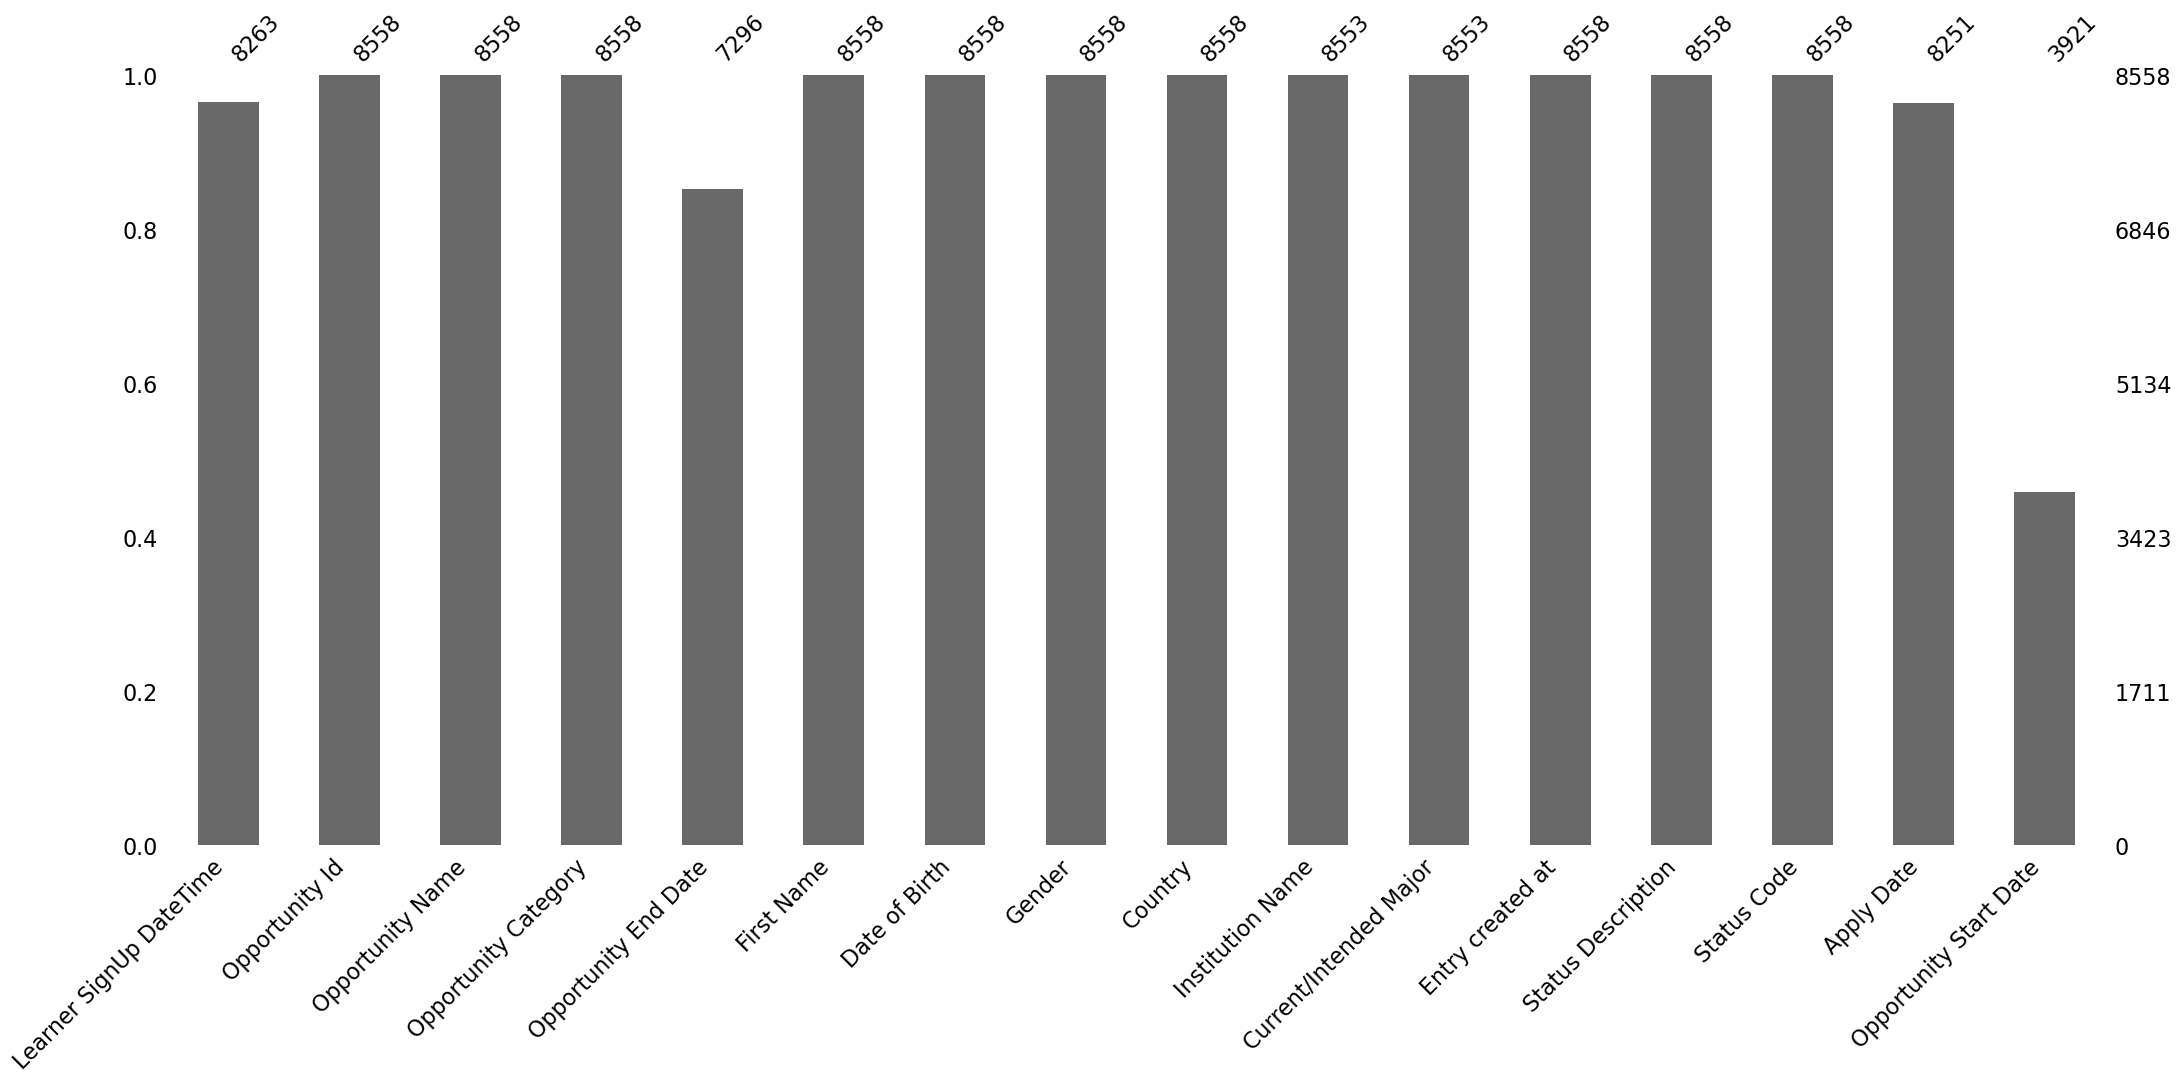

In [28]:
ms.bar(df)

In [29]:
df.columns

Index(['Learner SignUp DateTime', 'Opportunity Id', 'Opportunity Name',
       'Opportunity Category', 'Opportunity End Date', 'First Name',
       'Date of Birth', 'Gender', 'Country', 'Institution Name',
       'Current/Intended Major', 'Entry created at', 'Status Description',
       'Status Code', 'Apply Date', 'Opportunity Start Date'],
      dtype='object')

In [30]:
df[['Opportunity Name', 'Opportunity Category', 'First Name', 'Gender', 'Country', 'Institution Name',
       'Current/Intended Major', 'Status Description']] = df[['Opportunity Name', 'Opportunity Category', 'First Name', 'Gender', 'Country', 'Institution Name',
       'Current/Intended Major', 'Status Description']].astype('str')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8558 entries, 0 to 8557
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Learner SignUp DateTime  8263 non-null   datetime64[ns]
 1   Opportunity Id           8558 non-null   object        
 2   Opportunity Name         8558 non-null   object        
 3   Opportunity Category     8558 non-null   object        
 4   Opportunity End Date     7296 non-null   datetime64[ns]
 5   First Name               8558 non-null   object        
 6   Date of Birth            8558 non-null   datetime64[ns]
 7   Gender                   8558 non-null   object        
 8   Country                  8558 non-null   object        
 9   Institution Name         8558 non-null   object        
 10  Current/Intended Major   8558 non-null   object        
 11  Entry created at         8558 non-null   datetime64[ns]
 12  Status Description       8558 non-

In [32]:
df['Opportunity Name'].value_counts()

Opportunity Name
Career Essentials: Getting Started with Your Professional Journey    1423
Data Visualization                                                    980
Project Management                                                    836
Health Care Management                                                784
Digital Marketing                                                     559
Data Visualization Associate                                          551
Business Consulting                                                   483
Project Management Associate                                          478
Innovation & Entrepreneurship                                         419
CPR/AED Certification                                                 389
Digital Strategy Virtual Internship                                   331
Startup Mastery Workshop                                              262
Freelance Mastery workshop                                            237
Jump Start: Developin

In [33]:
df['Opportunity End Date'].isnull().sum()
                   


np.int64(1262)

In [34]:
# Conversion en datetime avec gestion des erreurs

df['Opportunity End Date']   = pd.to_datetime(df['Opportunity End Date'], errors='coerce', dayfirst=True)

# Extraire date et heure séparément

df['Opportunity_End_Date']   = df['Opportunity End Date'].dt.date
df['Opportunity_End_Time']   = df['Opportunity End Date'].dt.time


In [35]:
df.head()

,Learner SignUp DateTime,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity End Date,First Name,Date of Birth,Gender,Country,Institution Name,Current/Intended Major,Entry created at,Status Description,Status Code,Apply Date,Opportunity Start Date,Opportunity_End_Date,Opportunity_End_Time
0,2023-06-14 12:30:35,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Faria,2001-01-12,Female,Pakistan,Nwihs,Radiology,2024-03-11 12:01:41,Started,1080,2023-06-14 12:36:09,2022-11-03 18:30:39,2024-06-29,18:52:39
1,2023-05-01 05:29:16,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Poojitha,2000-08-16,Female,India,SAINT LOUIS,Information Systems,2024-03-11 12:01:41,Started,1080,2023-05-01 06:08:21,2022-11-03 18:30:39,2024-06-29,18:52:39
2,2023-04-09 20:35:08,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Emmanuel,2002-01-27,Male,United States,Illinois Institute of Technology,Computer Science,2024-03-11 12:01:41,Started,1080,NaT,2022-11-03 18:30:39,2024-06-29,18:52:39
3,2023-08-29 05:20:03,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Amrutha Varshini,1999-11-01,Female,United States,Saint Louis University,Information Systems,2024-03-11 12:01:41,Team Allocated,1070,2023-10-09 22:02:42,2022-11-03 18:30:39,2024-06-29,18:52:39
4,2023-01-06 15:26:36,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Vinay Varshith,2000-04-19,Male,United States,Saint Louis University,Computer Science,2024-03-11 12:01:41,Started,1080,2023-01-06 15:40:10,2022-11-03 18:30:39,2024-06-29,18:52:39


In [36]:
df['Opportunity Start Date'].isnull().sum()

np.int64(4637)

In [37]:
df['Opportunity_End_Date'].isnull().sum()

np.int64(1262)

In [38]:
df['Opportunity Start Date'].isnull().sum()

np.int64(4637)

In [39]:
df['Opportunity End Date'].isnull().sum()

np.int64(1262)

In [40]:
df.drop(columns=['Opportunity_Start_Date', 'Opportunity_Start_Time'], inplace=True)

KeyError: "['Opportunity_Start_Date', 'Opportunity_Start_Time'] not found in axis"

In [ ]:
ms.bar(df)

In [ ]:
df['Opportunity Start Date'] = pd.to_datetime(df['Opportunity Start Date'], errors='coerce', dayfirst=True)
df['Opportunity_Start_Date'] = df['Opportunity Start Date'].dt.date
df['Opportunity_Start_Time'] = df['Opportunity Start Date'].dt.time

In [ ]:
df.head()

In [ ]:
# S'assurer que la colonne est bien de type string
df['Opportunity Start Date'] = df['Opportunity Start Date'].astype(str)

# Extraire la partie date (avant l'espace)
df['Opportunity_Start_Date'] = df['Opportunity Start Date'].str.split(' ').str[0]

# Extraire la partie heure (après l'espace)
df['Opportunity_Start_Time'] = df['Opportunity Start Date'].str.split(' ').str[1]


In [ ]:
# S'assurer que la colonne est bien de type string
df['Opportunity End Date'] = df['Opportunity End Date'].astype(str)

# Extraire la partie date (avant l'espace)
df['Opportunity_End_Date'] = df['Opportunity End Date'].str.split(' ').str[0]

# Extraire la partie heure (après l'espace)
df['Opportunity_End_Time'] = df['Opportunity End Date'].str.split(' ').str[1]


In [ ]:
# S'assurer que la colonne est bien de type string
df['Learner SignUp DateTime'] = df['Learner SignUp DateTime'].astype(str)

# Extraire la partie date (avant l'espace)
df['Learner_SignUp_Date'] = df['Learner SignUp DateTime'].str.split(' ').str[0]

# Extraire la partie heure (après l'espace)
df['Learner_SignUp_Time'] = df['Learner SignUp DateTime'].str.split(' ').str[1]


In [ ]:
ms.bar(df)

In [ ]:
df.to_csv("../data/processed/RIT+Opportunity+Wise+Data+-+Sheet1_processed.csv", index=False)

In [ ]:
df['Opportunity Start Date'].isnull().sum()

In [ ]:
df.drop(columns=['Learner_SignUp_DateTime'], inplace=True)


In [ ]:
df_processed = pd.read_csv("../data/processed/RIT+Opportunity+Wise+Data+-+Sheet1_processed.csv")

In [ ]:
df_processed['Opportunity_Duration'] = pd.to_datetime(df['Opportunity_End_Date']) - pd.to_datetime(df['Opportunity_Start_Date'])

In [ ]:
df_processed.head()

In [ ]:
df_processed.to_csv("../data/processed/RIT+Opportunity+Wise+Data+-+Sheet1_final.csv", index=False)

In [ ]:
df_processed['Opportunity_Duration'].value_counts()

In [ ]:
ms.bar(df_processed)

In [ ]:
df_ex = pd.read_csv("../data/raw/new_version.csv")

In [ ]:
ms.bar(df_ex)

In [ ]:
df['Opportunity Start Date'].value_counts()



we can focus on just these 3 key points:

Dataset Volume: Total number of learners/records in the dataset (e.g., Total participants = X).

Status Distribution (Crucial): A quick breakdown (counts and percentages) of the target variable. For example:

Started: X (X%)

Team Allocated: X (X%)

Waitlisted: X (X%)

Withdrawn: X (X%)

Key Numeric Features (Metrics): If we have columns like engagement hours, age, or days active, just list the Mean (Average) and Median to show the general trend.

Here is the exact checklist of what we need for the summary:

1. For Qualitative (Categorical) Columns:
We want to find the Mode (the most frequent value) and the Percentage Distribution for these specific columns:

Status Description (e.g., % of Team Allocated, Started, Rejected, etc.)

Country (e.g., top countries participating)

Gender (e.g., male vs. female ratio)

Opportunity Category (e.g., % of Internships vs. Courses)

2. For Quantitative (Numerical) Columns:
If we extract or compute any numerical values (for example, if we calculate Age from the Date of Birth column), we need to provide:

Mean (Average)

Median (Middle value)

Mode (Most common value)

Just a clean bulleted list or a small table showing these metrics for each column will be perfect. It will keep the report clear, concise, and highly professional!

In [ ]:
df.head()

In [ ]:
df_raw = pd.read_csv("../data/RIT+Opportunity+Wise+Data+-+Sheet1.csv")

In [ ]:
ms.bar(df_raw)